In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from Function_file import Predict_current_charges,Predict_revenue

In [30]:
def import_csv_file(filepath):
    try:
        df = pd.read_csv(filepath)
        return df
    except FileNotFoundError as e:
        print(f"File not found: {e}")
    except pd.errors.EmptyDataError as e:
        print(f"Empty file: {e}")
    except pd.errors.ParserError as e:
        print(f"Parse error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

def top_n_developments_by_consumption(df, n):
    top_n_developments = df.groupby('Development_Name')['Consumption_(HCF)'].sum().sort_values(ascending=False).head(n)
    top_n_developments.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Top {n} Developments by Total Water Consumption (HCF)')
    plt.xlabel('Development Name')
    plt.ylabel('Total Water Consumption (HCF)')
    plt.show()

def least_n_developments_by_consumption(df, n):
    least_n_developments = df.groupby('Development_Name')['Consumption_(HCF)'].sum().sort_values().head(n)
    least_n_developments.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Least {n} Developments by Total Water Consumption (HCF)')
    plt.xlabel('Development Name')
    plt.ylabel('Total Water Consumption (HCF)')
    plt.show()

def percentage_consumption_by_borough(df):
    borough_consumption = df.groupby('Borough')['Consumption_(HCF)'].sum()
    borough_consumption.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%')
    plt.title('Percentage of Water Consumption by Borough')
    plt.ylabel('')
    plt.show()

def top_n_developments_by_charges(df, n):
    top_n_developments = df.groupby('Development_Name')[['Water&Sewer_Charges', 'Other_Charges']].sum().sort_values(by='Water&Sewer_Charges', ascending=False).head(n)
    top_n_developments.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title(f'Water & Sewer Charges vs. Other Charges by Development Name (Top {n})')
    plt.xlabel('Development Name')
    plt.ylabel('Total Charges')
    plt.show()

def top_n_accounts_by_charges(df, n):
    top_n_accounts = df.groupby('Account_Name')['Current_Charges'].sum().sort_values(ascending=False).head(n)
    top_n_accounts.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Top {n} Accounts by Total Current Charges')
    plt.xlabel('Account Name')
    plt.ylabel('Total Current Charges')
    plt.show()

def least_n_accounts_by_charges(df, n):
    least_n_accounts = df.groupby('Account_Name')['Current_Charges'].sum().sort_values().head(n)
    least_n_accounts.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Least {n} Accounts by Total Current Charges')
    plt.xlabel('Account Name')
    plt.ylabel('Total Current Charges')
    plt.show()

def percentage_meters_with_amr(df):
    amr_percentage = df['Meter_AMR'].value_counts()
    amr_percentage.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%')
    plt.title('Percentage of Meters with AMR Capability')
    plt.ylabel('')
    plt.show()

def average_days_by_rate_class(df):
    avg_days_rate_class = df.groupby('Rate_Class')['Days'].mean()
    avg_days_rate_class.plot(kind='bar', figsize=(10, 6))
    plt.title('Average Days in Billing Period by Rate Class')
    plt.xlabel('Rate Class')
    plt.ylabel('Average Days')
    plt.show()
    
def calculate_actual_vs_estimated_consumption(df):
    # Convert 'Estimated' column to 0 for 'N' and 1 for 'Y'
    df['Estimated'] = df['Estimated'].map({'N': 0, 'Y': 1})

    # Calculate the sum of consumption for actual and estimated for each development
    consumption_actual = df[df['Estimated'] == 0].groupby('Development_Name')['Consumption_(HCF)'].sum()
    consumption_estimated = df[df['Estimated'] == 1].groupby('Development_Name')['Consumption_(HCF)'].sum()

    # Reindex each series by the index of the other series, filling missing values with 0
    consumption_actual = consumption_actual.reindex(consumption_estimated.index, fill_value=0)
    consumption_estimated = consumption_estimated.reindex(consumption_actual.index, fill_value=0)

    # Sort both series by the sum of actual and estimated consumption, and take the top 20
    total_consumption = consumption_actual + consumption_estimated
    top_20_developments = total_consumption.sort_values(ascending=False).head(20).index

    # Plot the data
    plt.figure(figsize=(12, 6))
    plt.bar(top_20_developments, consumption_actual.loc[top_20_developments], label='Actual')
    plt.bar(top_20_developments, consumption_estimated.loc[top_20_developments], bottom=consumption_actual.loc[top_20_developments], label='Estimated')
    plt.xlabel('Development Name')
    plt.ylabel('Consumption (HCF)')
    plt.title('Actual vs. Estimated Consumption (HCF) by Development Name (Top 20)')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_water_consumption_heatmap(df):
    # Extract month from the Revenue_Month column
    df['Revenue_Month'] = pd.to_datetime(df['Revenue_Month'])
    df['Month'] = df['Revenue_Month'].dt.month

    # Create a pivot table
    pivot_table = df.pivot_table(index='Month', columns='Borough', values='Consumption_(HCF)', aggfunc=np.sum)

    # Plot heatmap
    sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".0f")
    plt.title('Water Consumption (HCF) by Revenue Month and Borough')
    plt.xlabel('Borough')
    plt.ylabel('Month')
    plt.show()

 HEAD : 

 Development_Name                        BAY VIEW
Borough                                   QUEENS
Account_Name                            BAY VIEW
Location               BLD 25 - Community Center
Meter_AMR                                   NONE
Meter_Scope                     Community Center
TDS                                         92.0
EDP                                          670
RC_Code                                  Q009100
Funding_Source                MIXED FINANCE/LLC1
AMP                                 NY005020920P
Vendor_Name            NEW YORK CITY WATER BOARD
UMIS_BILL_ID                             8870760
Revenue_Month                            2020-04
Service_Start_Date                    12/23/2019
Service_End_Date                      04/23/2020
Days                                        34.0
Meter_Number                           K13060723
Estimated                                      N
Current_Charges                           258.35
Rate_Clas

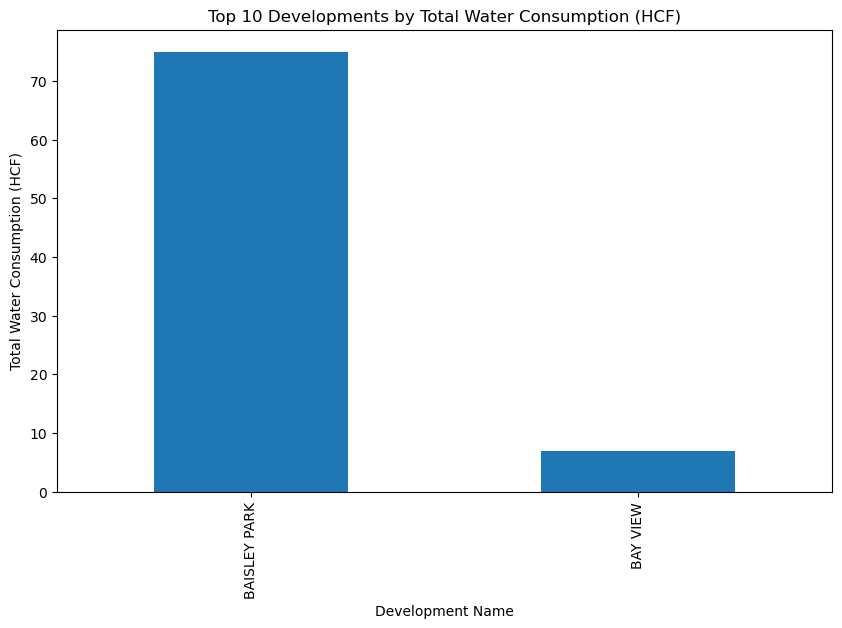

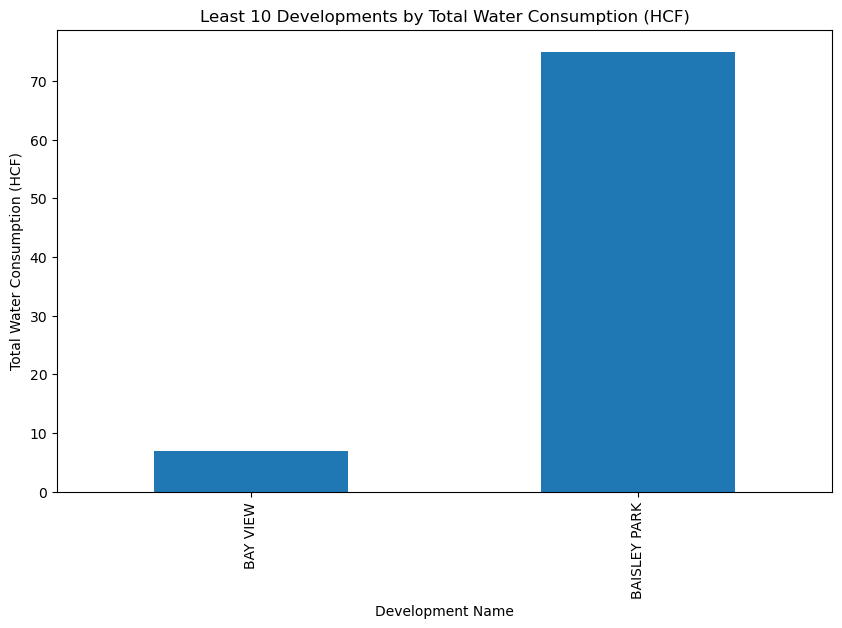

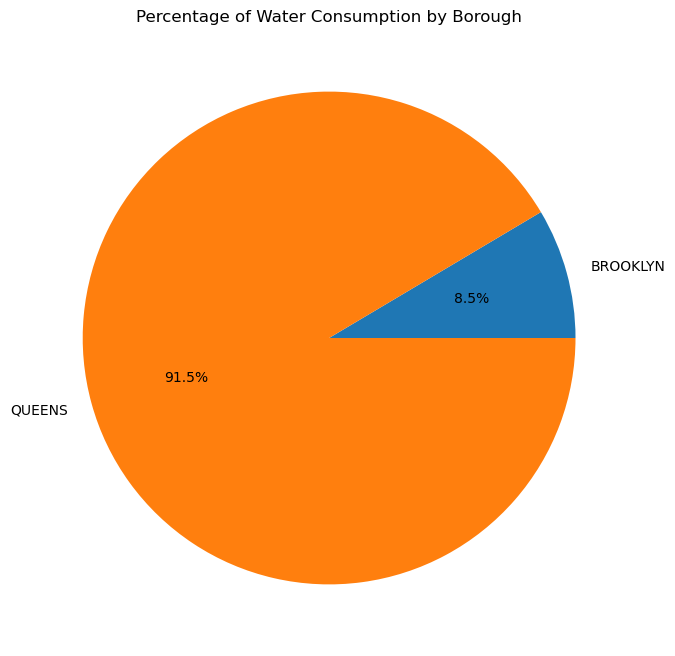

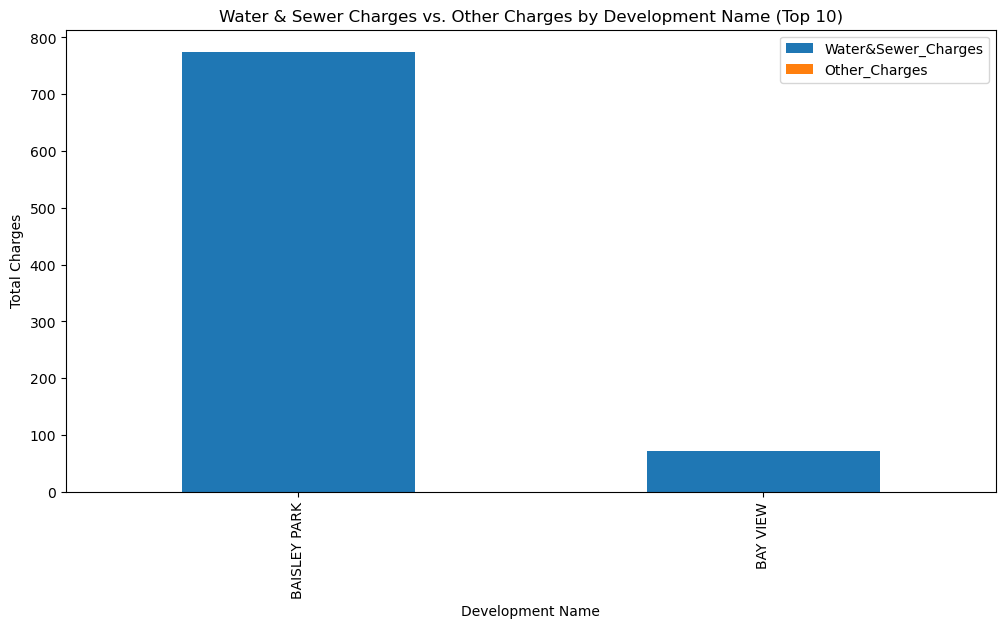

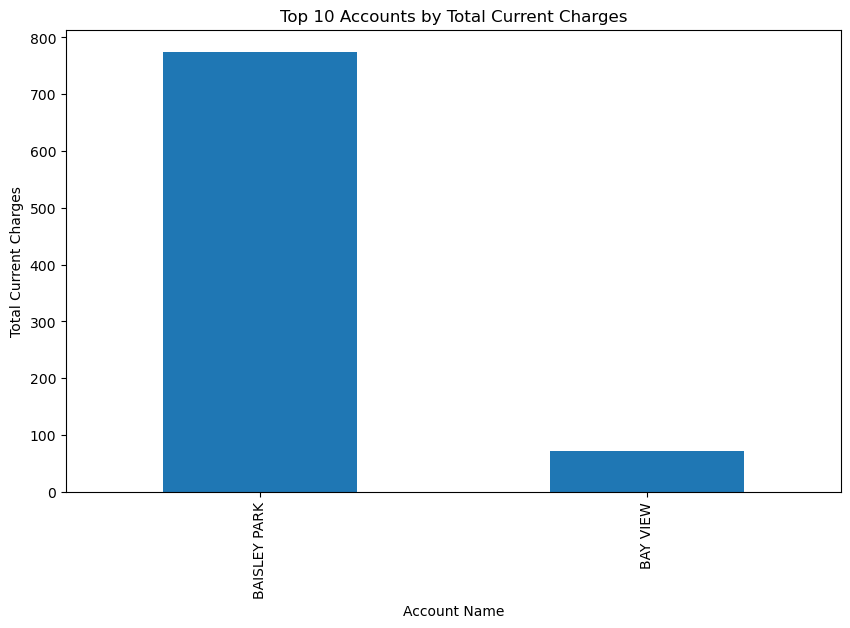

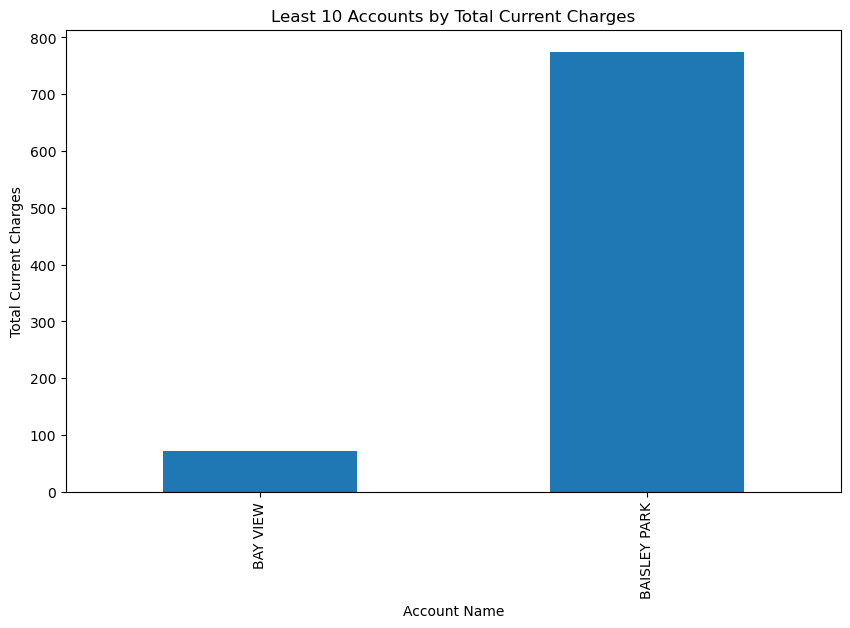

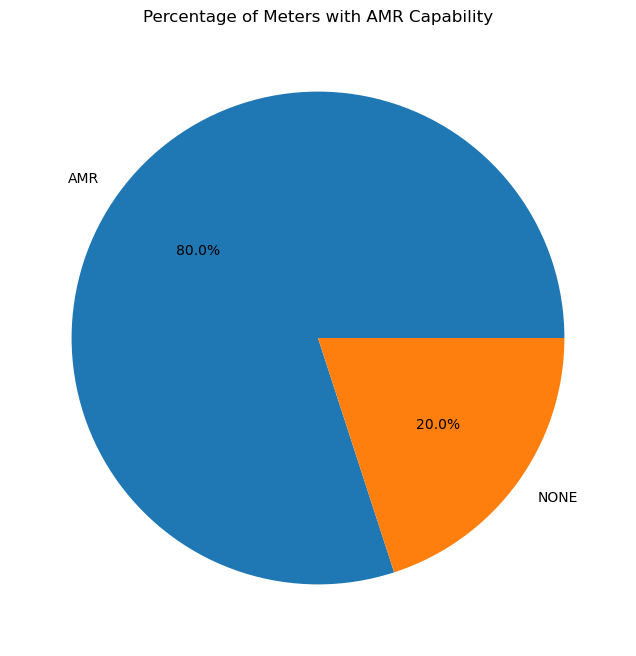

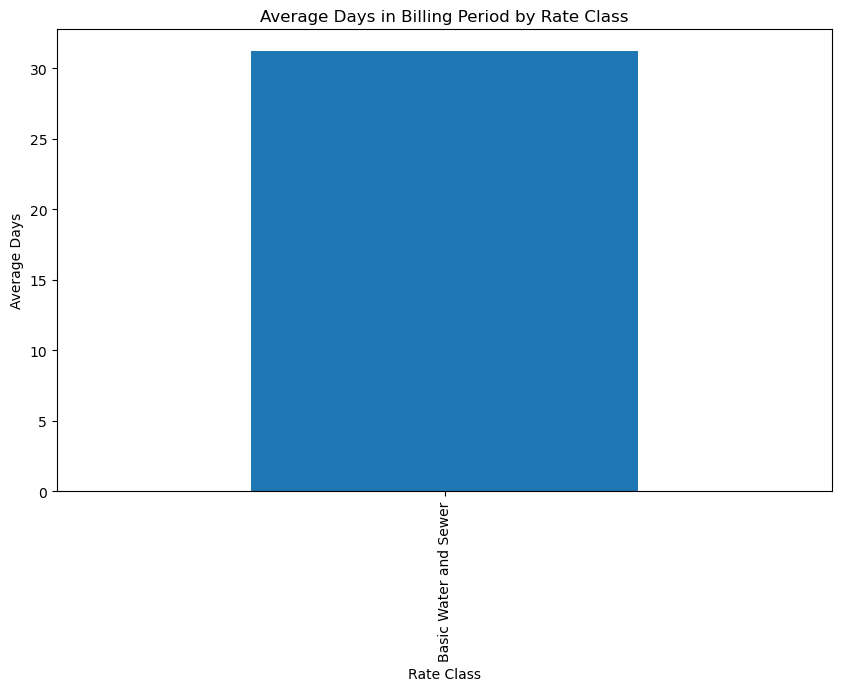

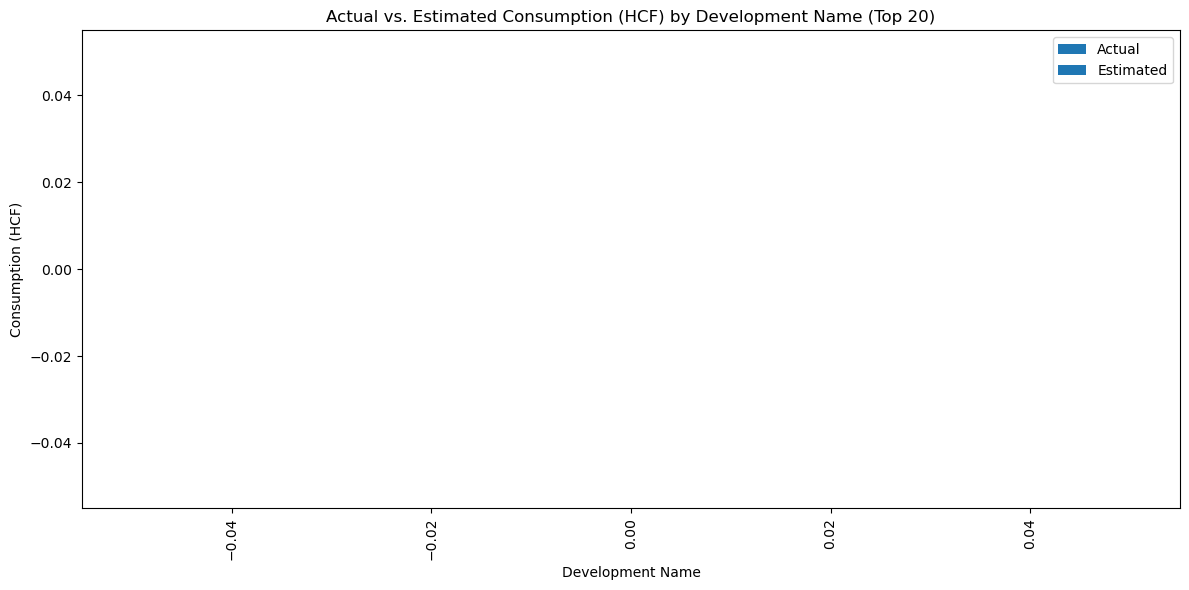

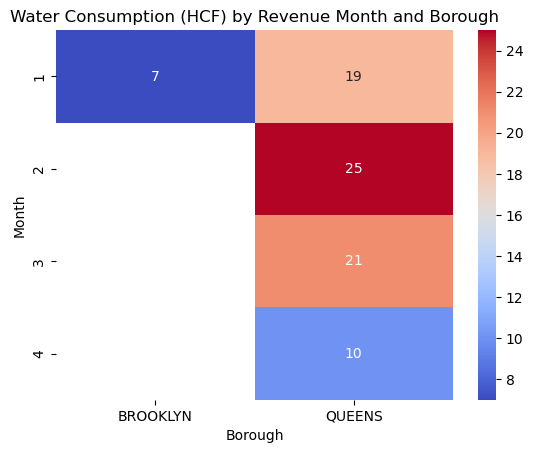

In [48]:
if __name__ == '__main__':

    # Load the CSV data into a Pandas DataFrame
    df = import_csv_file("C:/Users/16172/Downloads/Water_Consumption_And_Cost__2013_-_Feb_2023_ (1).csv")
    print(f" HEAD : \n\n {df.head().max()}")

    # Data cleaning and preparation steps
    df['Service_Start_Date'] = pd.to_datetime(df['Service_Start_Date'])
    df['Service_End_Date'] = pd.to_datetime(df['Service_End_Date'])
    categorical_columns = ['Development_Name', 'Location', 'Meter_AMR', 'Meter_Scope', 'AMP', 'Rate_Class', 'Funding_Source']
    for column in categorical_columns:
        mode = df[column].mode()[0]
        df[column].fillna(mode, inplace=True)
    numeric_columns = ['TDS', 'Days']
    for column in numeric_columns:
        median = df[column].median()
        df[column].fillna(median, inplace=True)
    df['TDS'] = df['TDS'].astype(int)
    df['Days'] = df['Days'].astype(int)

    # Generate some plots and summary statistics
    top_n_developments_by_consumption(df, 10)
    least_n_developments_by_consumption(df, 10)
    percentage_consumption_by_borough(df)
    top_n_developments_by_charges(df, 10)
    top_n_accounts_by_charges(df, 10)
    least_n_accounts_by_charges(df, 10)
    percentage_meters_with_amr(df)
    average_days_by_rate_class(df)
    calculate_actual_vs_estimated_consumption(df)
    plot_water_consumption_heatmap(df)


In [21]:
Predict_current_charges(df)

(       predicted_Current_charges
 0                      43.150000
 1                    1479.474865
 2                     152.160981
 3                     447.479349
 4                      65.622628
 ...                          ...
 10058                2697.825697
 10059                1550.412148
 10060                7593.252380
 10061                  89.587365
 10062                  65.622628
 
 [10063 rows x 1 columns],
 {'Accuracy': 0.7970197284914855})

In [22]:
Predict_revenue(df)

(       predicted_Revenue
 0              43.150000
 1            1480.094487
 2             152.048958
 3             447.356386
 4              51.593920
 ...                  ...
 10058        2718.187829
 10059        1551.991412
 10060        7632.746037
 10061          89.627646
 10062          51.593920
 
 [10063 rows x 1 columns],
 {'Accuracy': 0.7981789745613128})